In [22]:
import sys
from pathlib import Path

Duong_Dan_Goc = Path(r"D:\HR Analytics")

sys.path.append(
    str(Duong_Dan_Goc / "python" / "src")
)

MODEL_DIR = Duong_Dan_Goc / "python" / "models"
OUTPUT_DIR = Duong_Dan_Goc / "python" / "outputs"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)   
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from db import get_engine

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    classification_report,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

from sklearn.base import clone




In [2]:
engine = get_engine()
query="""
select *
from dw.View_ML_NhanVien
order by NgayThang, MaNV
"""
df = pd.read_sql(query, engine)
df["NgayThang"] = pd.to_datetime(df["NgayThang"])
df.head()

,MaNV,NgayThang,Nam,PhongBan,ChucDanh,CapBacCongViec,Tuoi,KhoangCachTuNha,SoLuongDuAn,SoGioTrungBinhThang,LamThemGio,DiemDanhGiaHieuSuat,DiemHaiLongCongViec,DiemHaiLongMoiTruong,ThuNhapThang,SoNamTaiCongTy,SoNamTuLanThangChucCuoi,DuocThangChucNamTruoc,CoNghiViec
0,5,2018-01-01,2018,Information Technology,IT Support,2,41,15,5,194,False,3,2,3,16936000,7,7,False,0
1,6,2018-01-01,2018,Sales,Sales Supervisor,1,29,16,3,206,False,4,4,3,11779000,7,7,False,0
2,7,2018-01-01,2018,Operations,Operations Manager,2,28,36,1,177,False,2,2,3,15588000,4,4,False,1
3,8,2018-01-01,2018,Human Resources,C&B Specialist,3,35,3,4,240,True,3,1,4,33357000,6,6,False,0
4,10,2018-01-01,2018,Human Resources,C&B Specialist,2,38,35,3,166,False,4,2,2,15353000,4,4,False,0


In [3]:
# Tạo dataset chỉ lấy ngày 01/01
df_du_doan = df[
    (df["NgayThang"].dt.month == 1) &
    (df["NgayThang"].dt.day == 1)
].copy()

# Mục tiêu dự đoán là có nghỉ việc trong 12 tháng hay không
df_du_doan = df_du_doan.rename(
    columns={
        "CoNghiViec": "CoNghiViec12Thang"
    }
)
muc_tieu = "CoNghiViec12Thang"

In [4]:
train = df_du_doan[
    df_du_doan["Nam"].between(
        2018,
        2023
    )
].copy()

valid = df_du_doan[
    df_du_doan["Nam"] == 2024
].copy()

test = df_du_doan[
    df_du_doan["Nam"] == 2025
].copy()

In [5]:
featurea_So= [
    "Tuoi",
    "KhoangCachTuNha",
    "SoLuongDuAn",
    "SoGioTrungBinhThang",
    "DiemDanhGiaHieuSuat",
    "DiemHaiLongCongViec",
    "DiemHaiLongMoiTruong",
    "ThuNhapThang",
    "SoNamTaiCongTy",
    "SoNamTuLanThangChucCuoi",
    "CapBacCongViec"
]
features_Nhi_Phan = [
    "LamThemGio",
    "DuocThangChucNamTruoc"
]
features_danh_muc = [
    "PhongBan",
    "ChucDanh"
]
feature_cot =( featurea_So + features_Nhi_Phan + features_danh_muc)

In [6]:
X_train = train[
    feature_cot
].copy()

y_train = train[
    muc_tieu
].copy()

X_valid = valid[
    feature_cot
].copy()

y_valid = valid[
    muc_tieu
].copy()

X_test = test[
    feature_cot
].copy()

y_test = test[
    muc_tieu
].copy()

Train: (25174, 15)
Validation: (4361, 15)
Test: (4431, 15)


In [8]:
tree_tien_xu_ly = ColumnTransformer(
    transformers=[
        (
            "so",
            "passthrough",
            featurea_So
        ),

        (
            "nhi_phan",
            "passthrough",
            features_Nhi_Phan
        ),

        (
            "danh_muc",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            features_danh_muc
        )
    ]
)

In [9]:
ds_max_depth = [
    3,
    4,
    5,
    6,
    8,
    10
]

ds_min_leaf = [
    5,
    10,
    20,
    30, 
    50
]

dt_min_split = [
    2,
    10,
    20
]
ds_criterion = [
    "gini",
    "entropy"
]

ds_class_weight = [
    None,
    "balanced"
]

In [11]:
ket_qua_tree = []

for max_depth in ds_max_depth:

    for min_leaf in (
        ds_min_leaf
    ):

        for criterion in (
            ds_criterion
        ):

            for class_weight in (
                ds_class_weight
            ):

                tree_pipeline = Pipeline(
                    steps=[
                        (
                            "tien_xu_ly",
                            tree_tien_xu_ly
                        ),
                        (
                            "mo_hinh",
                            DecisionTreeClassifier(
                                max_depth=max_depth,
                                min_samples_leaf=(
                                    min_leaf
                                ),
                                criterion=criterion,
                                class_weight=(
                                    class_weight
                                ),
                                random_state=42
                            )
                        )
                    ]
                )

                tree_pipeline.fit(
                    X_train,
                    y_train
                )

                xac_suat_valid = (
                    tree_pipeline
                    .predict_proba(
                        X_valid
                    )[:, 1]
                )

                ket_qua_tree.append({
                    "MaxDepth": max_depth,
                    "MinSamplesLeaf":
                        min_leaf,
                    "Criterion": criterion,
                    "ClassWeight":
                        str(class_weight),

                    "ROC_AUC":
                        roc_auc_score(
                            y_valid,
                            xac_suat_valid
                        ),

                    "PR_AUC":
                        average_precision_score(
                            y_valid,
                            xac_suat_valid
                        )
                })

In [13]:
ket_qua_tree = pd.DataFrame(
    ket_qua_tree
)
ket_qua_tree.sort_values(
    "PR_AUC",
    ascending=False
).head(20)

,MaxDepth,MinSamplesLeaf,Criterion,ClassWeight,ROC_AUC,PR_AUC
64,6,10,gini,None,0.701525,0.308589
60,6,5,gini,None,0.701507,0.307273
76,6,50,gini,None,0.699907,0.302027
66,6,10,entropy,None,0.699663,0.301815
78,6,50,entropy,None,0.693097,0.300085
68,6,20,gini,None,0.699198,0.298988
63,6,5,entropy,balanced,0.694542,0.298496
67,6,10,entropy,balanced,0.695499,0.298395
62,6,5,entropy,None,0.698869,0.298012
79,6,50,entropy,balanced,0.689141,0.295545


In [14]:
best_row_tree = (
    ket_qua_tree
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .iloc[0]
)

BEST_DEPTH = int(
    best_row_tree[
        "MaxDepth"
    ]
)

BEST_LEAF = int(
    best_row_tree[
        "MinSamplesLeaf"
    ]
)

BEST_CRITERION = (
    best_row_tree[
        "Criterion"
    ]
)

BEST_CLASS_WEIGHT = (
    None
    if best_row_tree[
        "ClassWeight"
    ] == "None"
    else "balanced"
)

print(
    "Max depth:",
    BEST_DEPTH
)

print(
    "Min samples leaf:",
    BEST_LEAF
)

print(
    "Criterion:",
    BEST_CRITERION
)

print(
    "Class weight:",
    BEST_CLASS_WEIGHT
)

Max depth: 6
Min samples leaf: 10
Criterion: gini
Class weight: None


In [15]:
best_tree = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(
                tree_tien_xu_ly
            )
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=BEST_DEPTH,
                min_samples_leaf=(
                    BEST_LEAF
                ),
                criterion=(
                    BEST_CRITERION
                ),
                class_weight=(
                    BEST_CLASS_WEIGHT
                ),
                random_state=42
            )
        )
    ]
)

best_tree.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Tuoi','KhoangCachTuNha','SoLuongDuAn',...,'DuocThangChucNamTruoc', 'PhongBan','ChucDanh']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('so', ...), ('nhi_phan', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [16]:
xac_suat_valid_tree = (
    best_tree
    .predict_proba(
        X_valid
    )[:, 1]
)

In [17]:
print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid,
        xac_suat_valid_tree
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_valid,
        xac_suat_valid_tree
    )
)

ROC-AUC: 0.7015248682125977
PR-AUC: 0.30858920831877845


In [18]:
ds_min_samples_split = [
    2,
    5,
    10,
    20,
    50,
    100
]

ds_min_samples_leaf_tinh_chinh = [
    5,
    10,
    15,
    20,
    30,
    50
]

ket_qua_tree_tinh_chinh = []

for min_split in ds_min_samples_split:

    for min_leaf in ds_min_samples_leaf_tinh_chinh:

        model_tree = Pipeline(
            steps=[
                (
                    "preprocessor",
                    tree_tien_xu_ly
                ),
                (
                    "model",
                    DecisionTreeClassifier(
                        max_depth=6,
                        min_samples_split=min_split,
                        min_samples_leaf=min_leaf,
                        criterion="gini",
                        class_weight=None,
                        random_state=42
                    )
                )
            ]
        )

        model_tree.fit(
            X_train,
            y_train
        )

        xac_suat = model_tree.predict_proba(
            X_valid
        )[:, 1]

        ket_qua_tree_tinh_chinh.append({
            "MaxDepth": 6,
            "MinSamplesSplit": min_split,
            "MinSamplesLeaf": min_leaf,
            "Criterion": "gini",
            "ClassWeight": "None",
            "ROC_AUC": roc_auc_score(
                y_valid,
                xac_suat
            ),
            "PR_AUC": average_precision_score(
                y_valid,
                xac_suat
            )
        })

ket_qua_tree_tinh_chinh = pd.DataFrame(
    ket_qua_tree_tinh_chinh
)

ket_qua_tree_tinh_chinh.sort_values(
    "PR_AUC",
    ascending=False
).head(15)

,MaxDepth,MinSamplesSplit,MinSamplesLeaf,Criterion,ClassWeight,ROC_AUC,PR_AUC
1,6,2,10,gini,None,0.701525,0.308589
19,6,20,10,gini,None,0.701525,0.308589
18,6,20,5,gini,None,0.701525,0.308589
7,6,5,10,gini,None,0.701525,0.308589
13,6,10,10,gini,None,0.701525,0.308589
12,6,10,5,gini,None,0.701507,0.307273
0,6,2,5,gini,None,0.701507,0.307273
6,6,5,5,gini,None,0.701507,0.307273
24,6,50,5,gini,None,0.700642,0.306709
25,6,50,10,gini,None,0.700642,0.306709


In [19]:
BEST_DEPTH = 6
BEST_SPLIT = 2
BEST_LEAF = 10
BEST_CRITERION = "gini"
BEST_CLASS_WEIGHT = None

best_tree = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_tien_xu_ly)
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=BEST_DEPTH,
                min_samples_split=BEST_SPLIT,
                min_samples_leaf=BEST_LEAF,
                criterion=BEST_CRITERION,
                class_weight=BEST_CLASS_WEIGHT,
                random_state=42
            )
        )
    ]
)

best_tree.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Tuoi','KhoangCachTuNha','SoLuongDuAn',...,'DuocThangChucNamTruoc', 'PhongBan','ChucDanh']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('so', ...), ('nhi_phan', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [20]:
xac_suat_valid_tree = (
    best_tree
    .predict_proba(X_valid)[:, 1]
)

In [21]:
print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid,
        xac_suat_valid_tree
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_valid,
        xac_suat_valid_tree
    )
)

ROC-AUC: 0.7015248682125977
PR-AUC: 0.30858920831877845


In [23]:
ds_precision_tree, ds_recall_tree, ds_threshold_tree = (
    precision_recall_curve(
        y_valid,
        xac_suat_valid_tree
    )
)

f1_tree = (
    2
    * ds_precision_tree[:-1]
    * ds_recall_tree[:-1]
    /
    (
        ds_precision_tree[:-1]
        + ds_recall_tree[:-1]
        + 1e-9
    )
)

vi_tri_tot_nhat_tree = np.argmax(
    f1_tree
)

best_threshold_tree = (
    ds_threshold_tree[
        vi_tri_tot_nhat_tree
    ]
)

print(
    "Threshold:",
    round(best_threshold_tree, 4)
)

print(
    "Precision:",
    round(
        ds_precision_tree[
            vi_tri_tot_nhat_tree
        ],
        4
    )
)

print(
    "Recall:",
    round(
        ds_recall_tree[
            vi_tri_tot_nhat_tree
        ],
        4
    )
)

print(
    "F1:",
    round(
        f1_tree[
            vi_tri_tot_nhat_tree
        ],
        4
    )
)

Threshold: 0.2
Precision: 0.3134
Recall: 0.4487
F1: 0.369


In [24]:
bang_threshold_tree = pd.DataFrame({
    "Threshold": ds_threshold_tree,
    "Precision": ds_precision_tree[:-1],
    "Recall": ds_recall_tree[:-1],
    "F1": f1_tree
})

bang_threshold_tree.sort_values(
    "F1",
    ascending=False
).head(15)

,Threshold,Precision,Recall,F1
25,0.200000,0.313369,0.448698,0.369018
26,0.211268,0.314410,0.441041,0.367113
21,0.169884,0.266068,0.589587,0.366667
27,0.213270,0.317926,0.431853,0.366234
23,0.191446,0.276863,0.540582,0.366183
22,0.174603,0.274555,0.543645,0.364851
20,0.165975,0.260899,0.595712,0.362873
19,0.153846,0.260549,0.595712,0.362535
29,0.225641,0.325581,0.407351,0.361905
28,0.214286,0.324786,0.407351,0.361413


In [25]:
nhan_du_doan_valid_tree = (
    xac_suat_valid_tree >= best_threshold_tree
).astype(int)

In [26]:
ket_qua_valid_tree = pd.DataFrame({
    "ChiSo": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],

    "GiaTri": [
        accuracy_score(
            y_valid,
            nhan_du_doan_valid_tree
        ),

        precision_score(
            y_valid,
            nhan_du_doan_valid_tree
        ),

        recall_score(
            y_valid,
            nhan_du_doan_valid_tree
        ),

        f1_score(
            y_valid,
            nhan_du_doan_valid_tree
        ),

        roc_auc_score(
            y_valid,
            xac_suat_valid_tree
        ),

        average_precision_score(
            y_valid,
            xac_suat_valid_tree
        )
    ]
})

ket_qua_valid_tree.round(4)

,ChiSo,GiaTri
0,Accuracy,0.7702
1,Precision,0.3134
2,Recall,0.4487
3,F1,0.3690
4,ROC_AUC,0.7015
5,PR_AUC,0.3086


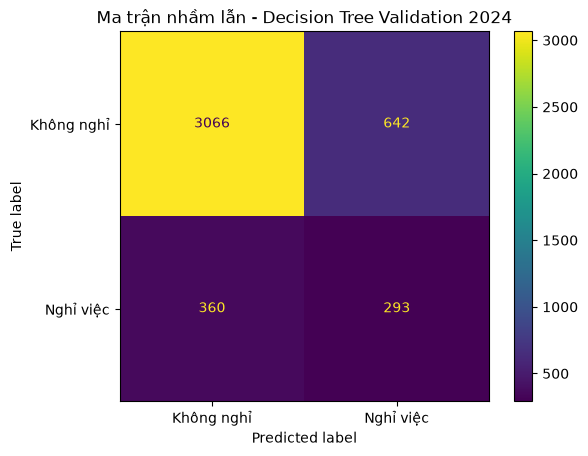

In [27]:
ma_tran_valid_tree = confusion_matrix(
    y_valid,
    nhan_du_doan_valid_tree
)

hien_thi_tree = ConfusionMatrixDisplay(
    confusion_matrix=ma_tran_valid_tree,
    display_labels=[
        "Không nghỉ",
        "Nghỉ việc"
    ]
)

hien_thi_tree.plot()

plt.title(
    "Ma trận nhầm lẫn - Decision Tree Validation 2024"
)

plt.show()

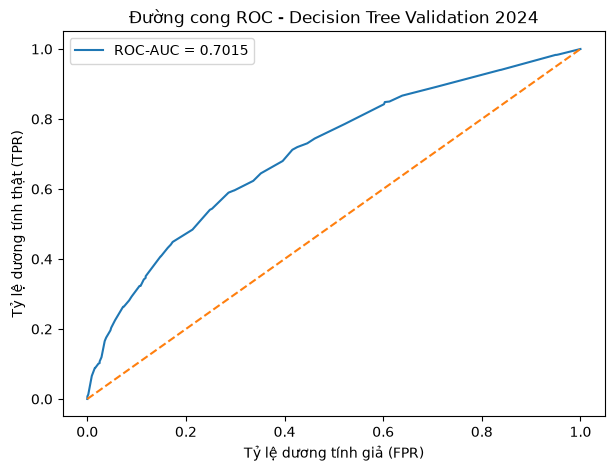

In [28]:
fpr_tree, tpr_tree, _ = roc_curve(
    y_valid,
    xac_suat_valid_tree
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_tree,
    tpr_tree,
    label=(
        f"ROC-AUC = "
        f"{roc_auc_score(y_valid, xac_suat_valid_tree):.4f}"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "Tỷ lệ dương tính giả (FPR)"
)

plt.ylabel(
    "Tỷ lệ dương tính thật (TPR)"
)

plt.title(
    "Đường cong ROC - Decision Tree Validation 2024"
)

plt.legend()

plt.show()

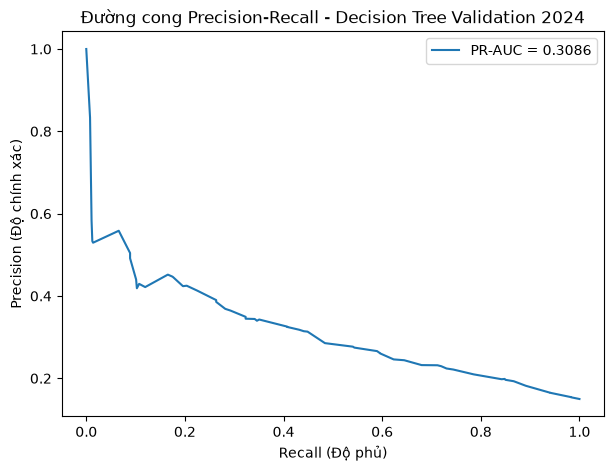

In [29]:
precision_curve_tree, recall_curve_tree, _ = (
    precision_recall_curve(
        y_valid,
        xac_suat_valid_tree
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve_tree,
    precision_curve_tree,
    label=(
        f"PR-AUC = "
        f"{average_precision_score(y_valid, xac_suat_valid_tree):.4f}"
    )
)

plt.xlabel(
    "Recall (Độ phủ)"
)

plt.ylabel(
    "Precision (Độ chính xác)"
)

plt.title(
    "Đường cong Precision-Recall - Decision Tree Validation 2024"
)

plt.legend()

plt.show()

In [30]:
final_train_tree = df_du_doan[
    df_du_doan["Nam"].between(
        2018,
        2024
    )
].copy()

final_test_tree = df_du_doan[
    df_du_doan["Nam"] == 2025
].copy()

In [31]:
X_final_train_tree = final_train_tree[
    feature_cot
].copy()

y_final_train_tree = final_train_tree[
    muc_tieu
].copy()

X_final_test_tree = final_test_tree[
    feature_cot
].copy()

y_final_test_tree = final_test_tree[
    muc_tieu
].copy()

In [32]:
final_tree = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(tree_tien_xu_ly)
        ),

        (
            "model",
            DecisionTreeClassifier(
                max_depth=6,
                min_samples_split=2,
                min_samples_leaf=10,
                criterion="gini",
                class_weight=None,
                random_state=42
            )
        )
    ]
)

final_tree.fit(
    X_final_train_tree,
    y_final_train_tree
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Tuoi','KhoangCachTuNha','SoLuongDuAn',...,'DuocThangChucNamTruoc', 'PhongBan','ChucDanh']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('so', ...), ('nhi_phan', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [33]:
xac_suat_test_tree = (
    final_tree
    .predict_proba(
        X_final_test_tree
    )[:, 1]
)

nhan_du_doan_test_tree = (
    xac_suat_test_tree
    >= best_threshold_tree
).astype(int)

In [34]:
ket_qua_test_tree = pd.DataFrame({
    "ChiSo": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],
    "GiaTri": [
        accuracy_score(
            y_final_test_tree,
            nhan_du_doan_test_tree
        ),

        precision_score(
            y_final_test_tree,
            nhan_du_doan_test_tree
        ),

        recall_score(
            y_final_test_tree,
            nhan_du_doan_test_tree
        ),

        f1_score(
            y_final_test_tree,
            nhan_du_doan_test_tree
        ),

        roc_auc_score(
            y_final_test_tree,
            xac_suat_test_tree
        ),

        average_precision_score(
            y_final_test_tree,
            xac_suat_test_tree
        )
    ]
})

ket_qua_test_tree.round(4)

,ChiSo,GiaTri
0,Accuracy,0.7504
1,Precision,0.2980
2,Recall,0.4910
3,F1,0.3709
4,ROC_AUC,0.7112
5,PR_AUC,0.2994


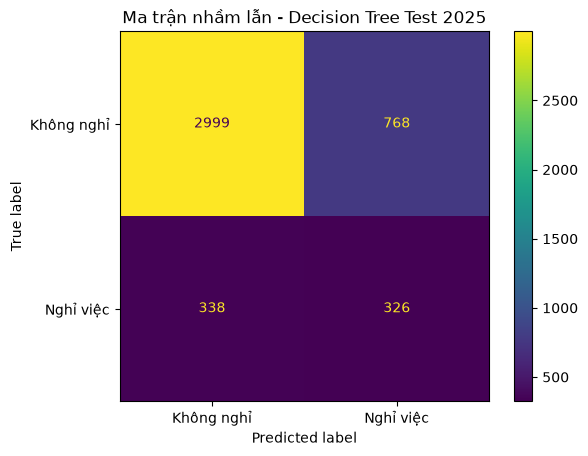

In [50]:
ma_tran_test_tree = confusion_matrix(
    y_final_test_tree,
    nhan_du_doan_test_tree
)

hien_thi_tree = ConfusionMatrixDisplay(
    confusion_matrix=ma_tran_test_tree,
    display_labels=[
        "Không nghỉ",
        "Nghỉ việc"
    ]
)

hien_thi_tree.plot()

plt.title(
    "Ma trận nhầm lẫn - Decision Tree Test 2025"
)
plt.savefig(
    OUTPUT_DIR
    / "tree_ma_tran_nham_lan_2025.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [37]:
print(
    classification_report(
        y_final_test_tree,
        nhan_du_doan_test_tree,
        target_names=[
            "Không nghỉ",
            "Nghỉ việc"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

  Không nghỉ     0.8987    0.7961    0.8443      3767
   Nghỉ việc     0.2980    0.4910    0.3709       664

    accuracy                         0.7504      4431
   macro avg     0.5984    0.6435    0.6076      4431
weighted avg     0.8087    0.7504    0.7734      4431



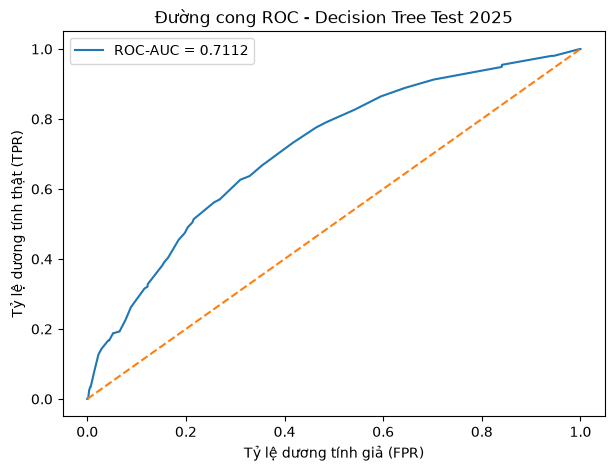

In [51]:
fpr_tree_test, tpr_tree_test, _ = roc_curve(
    y_final_test_tree,
    xac_suat_test_tree
)

roc_auc_tree_test = roc_auc_score(
    y_final_test_tree,
    xac_suat_test_tree
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_tree_test,
    tpr_tree_test,
    label=f"ROC-AUC = {roc_auc_tree_test:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "Tỷ lệ dương tính giả (FPR)"
)

plt.ylabel(
    "Tỷ lệ dương tính thật (TPR)"
)

plt.title(
    "Đường cong ROC - Decision Tree Test 2025"
)

plt.legend()
plt.savefig(
    OUTPUT_DIR / "tree_roc_2025.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

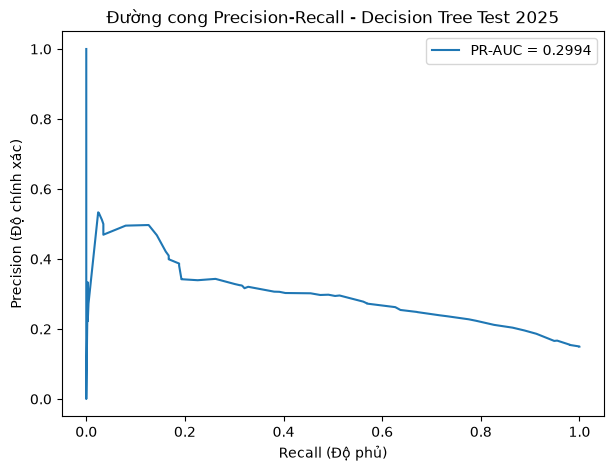

In [52]:
precision_tree_test, recall_tree_test, _ = (
    precision_recall_curve(
        y_final_test_tree,
        xac_suat_test_tree
    )
)

pr_auc_tree_test = average_precision_score(
    y_final_test_tree,
    xac_suat_test_tree
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_tree_test,
    precision_tree_test,
    label=f"PR-AUC = {pr_auc_tree_test:.4f}"
)

plt.xlabel(
    "Recall (Độ phủ)"
)

plt.ylabel(
    "Precision (Độ chính xác)"
)

plt.title(
    "Đường cong Precision-Recall - Decision Tree Test 2025"
)

plt.legend()
plt.savefig(
    OUTPUT_DIR
    / "tree_precision_recall_2025.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [40]:
ket_qua_du_doan_tree = (
    final_test_tree[
        [
            "MaNV",
            "NgayThang",
            "Nam",
            "PhongBan",
            "ChucDanh"
        ]
    ]
    .copy()
)

ket_qua_du_doan_tree[
    "ThucTeNghiViec"
] = y_final_test_tree.values

ket_qua_du_doan_tree[
    "XacSuatNghiViec"
] = xac_suat_test_tree

ket_qua_du_doan_tree[
    "DuDoanNghiViec"
] = nhan_du_doan_test_tree

ket_qua_du_doan_tree[
    "NguongDuDoan"
] = best_threshold_tree

ket_qua_du_doan_tree.head(10)

,MaNV,NgayThang,Nam,PhongBan,ChucDanh,ThucTeNghiViec,XacSuatNghiViec,DuDoanNghiViec,NguongDuDoan
35210,1,2025-01-01,2025,Sales,Sales Representative,0,0.216393,1,0.2
35211,3,2025-01-01,2025,Finance,Finance Manager,0,0.195652,0,0.2
35212,4,2025-01-01,2025,Human Resources,Recruiter,0,0.128272,0,0.2
35213,5,2025-01-01,2025,Information Technology,IT Support,0,0.093567,0,0.2
35214,10,2025-01-01,2025,Human Resources,C&B Specialist,1,0.135135,0,0.2
35215,13,2025-01-01,2025,Sales,Sales Executive,1,0.303514,1,0.2
35216,21,2025-01-01,2025,Human Resources,Recruiter,0,0.403183,1,0.2
35217,24,2025-01-01,2025,Sales,Sales Representative,1,0.216393,1,0.2
35218,28,2025-01-01,2025,Human Resources,C&B Specialist,1,0.113976,0,0.2
35219,29,2025-01-01,2025,Human Resources,Recruiter,1,0.135135,0,0.2


In [41]:
bo_tien_xu_ly_tree = (
    final_tree
    .named_steps["preprocessor"]
)

ten_feature_tree = (
    bo_tien_xu_ly_tree
    .get_feature_names_out()
)

mo_hinh_tree = (
    final_tree
    .named_steps["model"]
)

do_quan_trong_tree = pd.DataFrame({
    "Feature": ten_feature_tree,
    "Importance":
        mo_hinh_tree.feature_importances_
})

In [42]:
do_quan_trong_tree["Feature"] = (
    do_quan_trong_tree["Feature"]
    .str.replace(
        "so__",
        "",
        regex=False
    )
    .str.replace(
        "nhi_phan__",
        "",
        regex=False
    )
    .str.replace(
        "danh_muc__",
        "",
        regex=False
    )
)

In [43]:
do_quan_trong_tree = (
    do_quan_trong_tree
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

do_quan_trong_tree.head(15)

,Feature,Importance
0,LamThemGio,0.418104
1,DiemHaiLongCongViec,0.179173
2,SoGioTrungBinhThang,0.146016
3,DiemHaiLongMoiTruong,0.093061
4,SoNamTuLanThangChucCuoi,0.064670
5,SoLuongDuAn,0.030020
6,KhoangCachTuNha,0.019993
7,SoNamTaiCongTy,0.013553
8,ThuNhapThang,0.012777
9,Tuoi,0.008451


In [44]:
import joblib

joblib.dump(
    final_tree,
    MODEL_DIR / "decision_tree_model.pkl"
)

['D:\\HR Analytics\\python\\models\\decision_tree_model.pkl']

In [45]:
ket_qua_test_tree.to_csv(
    OUTPUT_DIR / "decision_tree_test_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

In [46]:
ket_qua_du_doan_tree.to_csv(
    OUTPUT_DIR / "decision_tree_du_doan_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

In [47]:
do_quan_trong_tree.to_csv(
    OUTPUT_DIR
    / "decision_tree_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

In [48]:
ket_qua_tree.to_csv(
    OUTPUT_DIR / "decision_tree_tuning.csv",
    index=False,
    encoding="utf-8-sig"
)

In [49]:
bang_threshold_tree.to_csv(
    OUTPUT_DIR / "decision_tree_threshold.csv",
    index=False,
    encoding="utf-8-sig"
)